In [ ]:
import openmc
import openmc.mgxs as mgxs
#openmc.config['chain_file'] = 'chain_endfb71_pwr.xml'
openmc.config['cross_sections'] = '/run/media/nikita/dexp/lib80x_hdf5/cross_sections.xml'

In [2]:
from utils.materials import FuelMat, WaterMat

In [3]:
fuel = FuelMat()
water = WaterMat()

# fuel_cyl = openmc.ZCylinder(r=1)
# outer_cyl =  openmc.ZCylinder(r=2, boundary_type='reflective')

# fuel_cell = openmc.Cell(fill=fuel.mat, region=-fuel_cyl)
# water_cell = openmc.Cell(fill=water.mat, region=+fuel_cyl & -outer_cyl)

top = openmc.Plane(0,1,0,1, boundary_type='vacuum')
bottom = openmc.Plane(0,1,0,0, boundary_type='vacuum')
center = openmc.Plane(1,0,0,0, boundary_type='reflective')
outer = openmc.Plane(1,0,0,1, boundary_type='vacuum')

fuel_cell = openmc.Cell(fill=fuel.mat, region= +bottom & -top & +center & -outer)

universe = openmc.Universe(cells=[fuel_cell])

geom = openmc.Geometry(universe)
mats = openmc.Materials([fuel.mat, water.mat])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

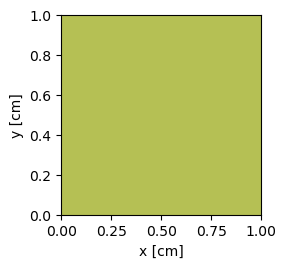

In [4]:
universe.plot()

In [5]:
mesh = openmc.RegularMesh()
mesh.dimension = [100,100,1]
mesh.lower_left = [0,0, -1]
mesh.upper_right = [1, 1, 1]

In [6]:
mesh_filter = openmc.MeshFilter(mesh)

In [7]:
# 1. Define 2-group structure (example)
groups = mgxs.EnergyGroups([0.001, 2])

# 2. Define a total cross section object for a specific material
# (assuming '1' is the ID of your material)
total_xs = mgxs.TotalXS(domain=mesh, energy_groups=groups)

In [8]:
total_xs.tallies

{'flux': Tally
 	ID             =	1
 	Name           =	
 	Filters        =	MeshFilter, EnergyFilter
 	Nuclides       =	total
 	Scores         =	['flux']
 	Estimator      =	tracklength
 	Multiply dens. =	True,
 'total': Tally
 	ID             =	2
 	Name           =	
 	Filters        =	MeshFilter, EnergyFilter
 	Nuclides       =	total
 	Scores         =	['total']
 	Estimator      =	tracklength
 	Multiply dens. =	True}

In [ ]:
tally = openmc.Tally(name="flux_mesh")
tally.filters = [mesh_filter]
tally.scores = ['flux', ]
tallies = openmc.Tallies( [tally] + list(total_xs.tallies.values()))

In [15]:
tally

Tally
	ID             =	3
	Name           =	flux_mesh
	Filters        =	MeshFilter
	Nuclides       =	
	Scores         =	['flux']
	Estimator      =	None
	Multiply dens. =	True

In [10]:
setting = openmc.Settings()
setting.batches = 500
setting.inactive = 100
setting.particles = 100_000

uniform_dist = openmc.stats.Box([0,0,0], [1,1,0])
setting.source = openmc.source.IndependentSource(space=uniform_dist, constraints={'fissionable': True})
setting.run_mode = 'eigenvalue'

In [11]:
model = openmc.Model(
    geometry=geom,
    materials=mats,
    settings=setting,
    tallies=tallies
)

In [12]:
model.run(cwd='./grids')

/home/nikita/.conda/envs/science/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=1.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/run/media/nikita/e40c1d03-27f0-4c5f-b778-1710c9a842d0/PycharmProjects/OpenMC/grids/statepoint.500.h5')

In [13]:
sp = openmc.StatePoint("grids/statepoint.500.h5")
sp

In [ ]:
t = sp.tallies[2]
t.r

AttributeError: 'Tally' object has no attribute 'xs_results'

In [16]:
total_xs.get_xs(xs_type='macro')

ValueError: Unable to use tally arithmetic with Tally ID="2" since it does not contain any results.

In [ ]:
total_xs.load_from_statepoint(sp)

# Get the data in a pandas DataFrame
df = total_xs.get_pandas_dataframe(xs_type='macro')
print(df)

   cell  group in nuclide      mean  std. dev.
0     1         1   total  0.249498   0.000064


In [ ]:
for m in dir(sp):
    if m.startswith('_') or m.startswith('cmfd'):
        continue
    print(m)

add_volume_information
close
current_batch
date_and_time
entropy
filters
generations_per_batch
get_kinetics_parameters
get_tally
global_tallies
k_abs_tra
k_cmfd
k_col_abs
k_col_tra
k_combined
k_generation
keff
link_with_summary
meshes
n_batches
n_inactive
n_particles
n_realizations
path
photon_transport
run_mode
runtime
seed
source
source_present
sparse
stride
summary
tallies
tallies_present
tally_derivatives
version


In [ ]:
with open('./grids/tallies.out', 'r') as resfile:
    restext = resfile.readlines()
restext

[' ======================>     TALLY 1: FLUX_MESH     <=======================\n',
 '\n',
 ' Mesh Index (1, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 2.9701e-06 +/- 6.13283e-08\n',
 ' Mesh Index (2, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 2.96624e-06 +/- 5.22118e-08\n',
 ' Mesh Index (3, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 3.03528e-06 +/- 5.46273e-08\n',
 ' Mesh Index (4, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 3.00197e-06 +/- 5.40648e-08\n',
 ' Mesh Index (5, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 2.99874e-06 +/- 5.7454e-08\n',
 ' Mesh Index (6, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 2.98706e-06 +/- 5.45263e-08\n',
 ' Mesh Index (7, 1, 1)\n',
 '   Total Material\n',
 '     Flux                                 2.92823e-06 +/- 5.76215e-08\n',
 ' Mesh Index (8

In [ ]:
import numpy as np

In [ ]:
resdict = {}
for i in range(len(restext)):
    if restext[i].startswith(" Mesh Index"):
        key = restext[i].replace("Mesh Index", '').strip(" \n()")
        key = key.split(', ')
        key = (int(key[0]), int(key[1]))
        value = restext[i+2].replace('Flux', '').strip().replace(' ', '')
        value = value.split('+/-')
        value = (float(value[0]), float(value[1]))
        resdict[key] = value
resdict

{(1, 1): (2.9701e-06, 6.13283e-08),
 (2, 1): (2.96624e-06, 5.22118e-08),
 (3, 1): (3.03528e-06, 5.46273e-08),
 (4, 1): (3.00197e-06, 5.40648e-08),
 (5, 1): (2.99874e-06, 5.7454e-08),
 (6, 1): (2.98706e-06, 5.45263e-08),
 (7, 1): (2.92823e-06, 5.76215e-08),
 (8, 1): (3.08133e-06, 5.66914e-08),
 (9, 1): (2.9955e-06, 5.37836e-08),
 (10, 1): (3.0302e-06, 5.55968e-08),
 (11, 1): (3.05456e-06, 6.03184e-08),
 (12, 1): (2.98126e-06, 5.54832e-08),
 (13, 1): (3.02953e-06, 5.16084e-08),
 (14, 1): (2.96786e-06, 5.37067e-08),
 (15, 1): (2.92627e-06, 5.31087e-08),
 (16, 1): (2.96516e-06, 5.20837e-08),
 (17, 1): (2.97737e-06, 4.9499e-08),
 (18, 1): (3.02626e-06, 5.41984e-08),
 (19, 1): (3.00831e-06, 5.12152e-08),
 (20, 1): (2.93537e-06, 5.2909e-08),
 (21, 1): (2.87039e-06, 5.11429e-08),
 (22, 1): (2.95386e-06, 5.25709e-08),
 (23, 1): (2.9299e-06, 5.27643e-08),
 (24, 1): (2.9076e-06, 5.04112e-08),
 (25, 1): (2.88872e-06, 5.06103e-08),
 (26, 1): (2.89712e-06, 4.99348e-08),
 (27, 1): (2.89645e-06, 4.832

In [ ]:
resmat = np.zeros(list(resdict.keys())[-1])
for key, value in resdict.items():
    y, x = key
    f = value[0]
    resmat[x-1,y-1] = f
resmat/=resmat.max()

In [ ]:
resmat.argmax(keepdims=True)

array([[5005]])

In [ ]:
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

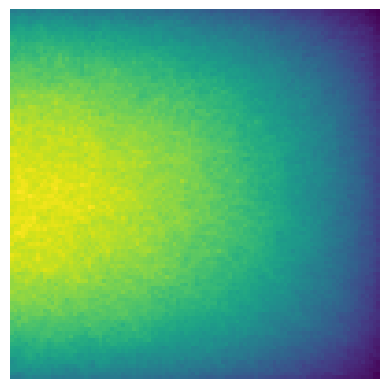

In [ ]:
plt.imshow(resmat)
plt.axis('off')

In [ ]:
rerrs = []
for key, value in resdict.items():
    y, x = key
    f, err = value
    rerrs.append(err/f*100)
rerrs

[2.064856402141342,
 1.7602014671773019,
 1.7997449988139482,
 1.8009773582014479,
 1.9159380273048014,
 1.8254169651764611,
 1.967792830481212,
 1.8398353957544307,
 1.7954798864964112,
 1.8347567817305792,
 1.974700120475617,
 1.8610654555456418,
 1.703511765851469,
 1.8096102915905736,
 1.8148940460039575,
 1.756522413630293,
 1.6625075150216464,
 1.7909366677020482,
 1.7024575259863512,
 1.8024644252683648,
 1.7817404603555613,
 1.7797356679057235,
 1.8008908153861907,
 1.7337735589489613,
 1.7519974244648147,
 1.7236013696360524,
 1.6683940686012186,
 1.714713970545213,
 1.7869618588041944,
 1.7285693006628435,
 1.7380250167336009,
 1.7690875559233135,
 1.9785333490471204,
 1.8544273726427287,
 1.73132415138592,
 1.798291437893592,
 1.7289966266906451,
 1.7804582646781304,
 1.7955910405186843,
 1.7759457186599295,
 1.7195424555364314,
 1.8044604988857742,
 1.7926025142890878,
 1.8901120403519198,
 1.918255716231489,
 1.9993765226542115,
 1.8847164728300152,
 1.8076637435016467,
 1

Text(0.5, 1.0, 'Ошибка, %')

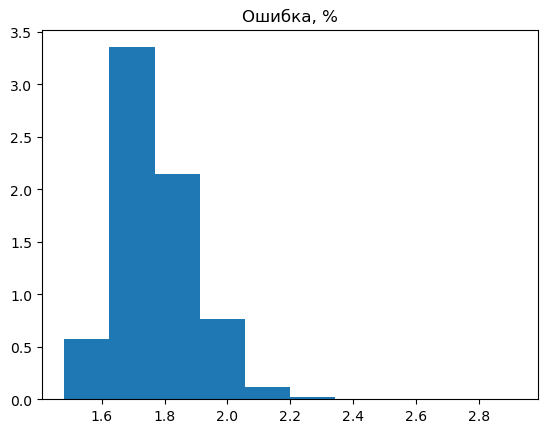

In [ ]:
plt.hist(rerrs, density=True)
plt.title('Ошибка, %')

In [ ]:
import h5py

In [ ]:


filename = "./grids/summary.h5"

h5 = h5py.File(filename,'r')

# datasetNames = [n for n in h5.keys()]
# for n in datasetNames:
#     print(n, h5[n])
#     try:
#         for m in h5[n]:
#             print(m)
#     except:
#         pass

for i in h5['materials']['material 1']:
    print(i)
# for i in h5['nuclides']['awrs']:
#     print(i)

h5.close()


atom_density
name
nuclide_densities
nuclides
